# Lab Work - 2.4

**Q1: Understanding Outliers**

**Q2: Outlier Detection & Removal using Z-Score Method**

**Q3: Outlier Detection & Removal using IQR Method**

## Q1. Outliers in Machine Learning - Theory & Manual Outlier Injection

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set style for better visualization
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Step 1: Generate 100 normally distributed Age values
np.random.seed(42)  # for reproducibility
age_data = np.random.normal(loc=35, scale=10, size=100)

# Step 2: Manually add 5 extreme outliers
outliers = [200, 150, -10, 170, 300]
age_with_outliers = np.concatenate([age_data, outliers])

print(f"Original dataset size: {len(age_data)}")
print(f"Dataset with outliers size: {len(age_with_outliers)}")
print(f"Added outliers: {outliers}")

Original dataset size: 100
Dataset with outliers size: 105
Added outliers: [200, 150, -10, 170, 300]


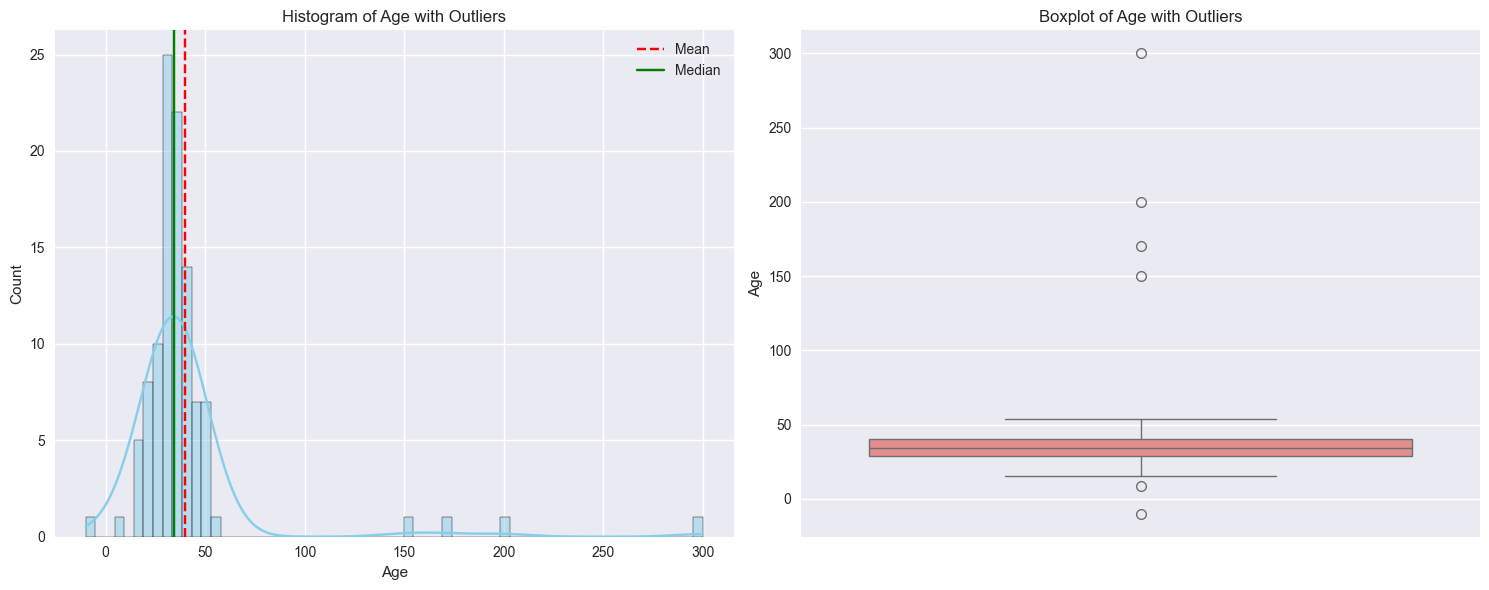

In [2]:
# Step 3: Plot Histogram and Boxplot
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histogram
sns.histplot(age_with_outliers, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Histogram of Age with Outliers')
axes[0].set_xlabel('Age')
axes[0].axvline(np.mean(age_with_outliers), color='red', linestyle='--', label='Mean')
axes[0].axvline(np.median(age_with_outliers), color='green', linestyle='-', label='Median')
axes[0].legend()

# Boxplot
sns.boxplot(y=age_with_outliers, ax=axes[1], color='lightcoral')
axes[1].set_title('Boxplot of Age with Outliers')
axes[1].set_ylabel('Age')

plt.tight_layout()
plt.show()

In [3]:
# Step 4: Comment on Mean vs Median
mean_age = np.mean(age_with_outliers)
median_age = np.median(age_with_outliers)

print(f"Mean of dataset with outliers: {mean_age:.2f}")
print(f"Median of dataset with outliers: {median_age:.2f}")
print("\nObservation:")
print("Outliers significantly affect the Mean, pulling it towards extreme values.")
print("The Median is more robust and remains closer to the center of the normal distribution.")

Mean of dataset with outliers: 40.06
Median of dataset with outliers: 34.28

Observation:
Outliers significantly affect the Mean, pulling it towards extreme values.
The Median is more robust and remains closer to the center of the normal distribution.


## Q2. Outlier Detection and Removal using Z-Score Method

In [4]:
# Using the same dataset from Q1
data = age_with_outliers.copy()

# Compute mean and standard deviation
mu = np.mean(data)
sigma = np.std(data)

print(f"Mean (μ): {mu:.2f}")
print(f"Standard Deviation (σ): {sigma:.2f}")

Mean (μ): 40.06
Standard Deviation (σ): 36.06


In [5]:
# Calculate Z-score for each data point
z_scores = (data - mu) / sigma

# Identify outliers: |Z| > 3
outlier_mask = np.abs(z_scores) > 3
outliers_z = data[outlier_mask]

print(f"Number of outliers detected by Z-score: {len(outliers_z)}")
print(f"Outliers: {outliers_z}")

Number of outliers detected by Z-score: 4
Outliers: [200. 150. 170. 300.]


In [6]:
# Remove outliers
cleaned_z = data[~outlier_mask]

print(f"Original size: {len(data)}")
print(f"Cleaned size (Z-score): {len(cleaned_z)}")

Original size: 105
Cleaned size (Z-score): 101


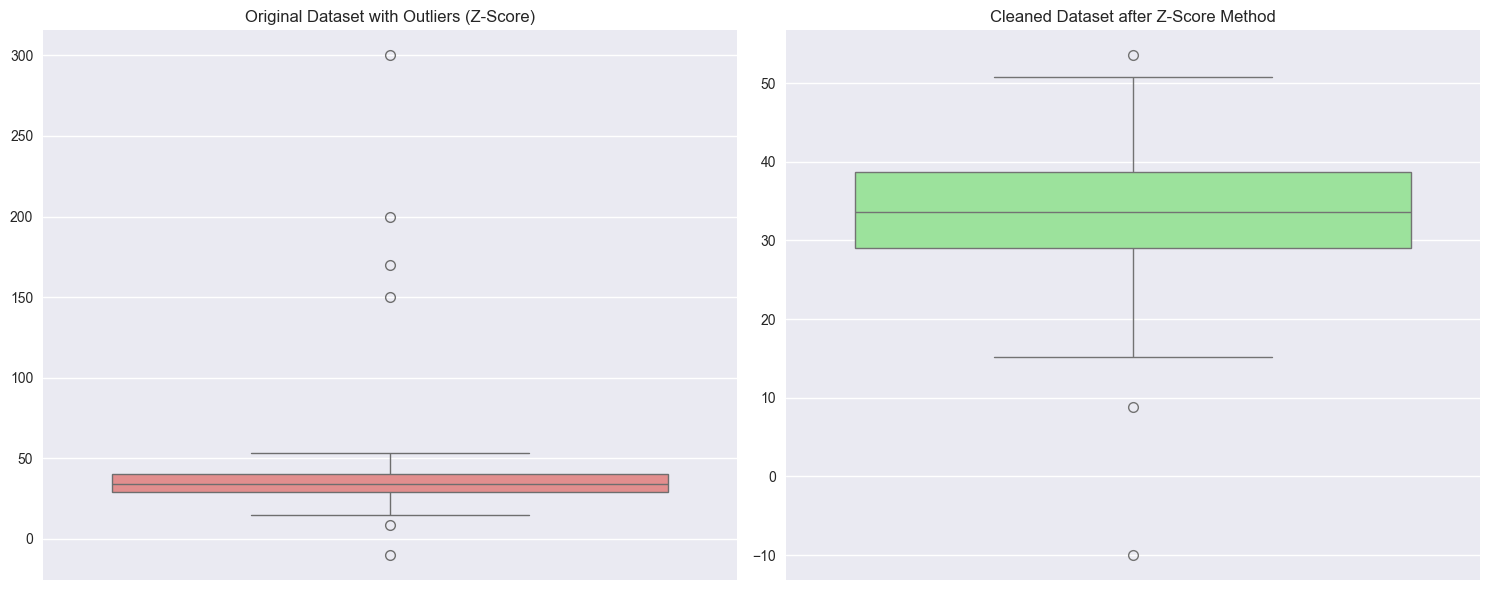

In [7]:
# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(y=data, ax=axes[0], color='lightcoral')
axes[0].set_title('Original Dataset with Outliers (Z-Score)')

sns.boxplot(y=cleaned_z, ax=axes[1], color='lightgreen')
axes[1].set_title('Cleaned Dataset after Z-Score Method')

plt.tight_layout()
plt.show()

## Q3. Outlier Detection and Removal using IQR Method

In [8]:
# Using the same original dataset
data_iqr = age_with_outliers.copy()

# Compute Q1, Q3 and IQR
Q1 = np.percentile(data_iqr, 25)
Q3 = np.percentile(data_iqr, 75)
IQR = Q3 - Q1

print(f"Q1 (25th percentile): {Q1:.2f}")
print(f"Q3 (75th percentile): {Q3:.2f}")
print(f"IQR: {IQR:.2f}")

Q1 (25th percentile): 28.99
Q3 (75th percentile): 40.43
IQR: 11.43


In [9]:
# Calculate lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower Bound: {lower_bound:.2f}")
print(f"Upper Bound: {upper_bound:.2f}")

Lower Bound: 11.85
Upper Bound: 57.57


In [10]:
# Identify outliers
outlier_iqr_mask = (data_iqr < lower_bound) | (data_iqr > upper_bound)
outliers_iqr = data_iqr[outlier_iqr_mask]

print(f"Number of outliers detected by IQR: {len(outliers_iqr)}")
print(f"Outliers: {outliers_iqr}")

Number of outliers detected by IQR: 6
Outliers: [  8.80254896 200.         150.         -10.         170.
 300.        ]


In [11]:
# Remove outliers
cleaned_iqr = data_iqr[~outlier_iqr_mask]

print(f"Original size: {len(data_iqr)}")
print(f"Cleaned size (IQR): {len(cleaned_iqr)}")

Original size: 105
Cleaned size (IQR): 99


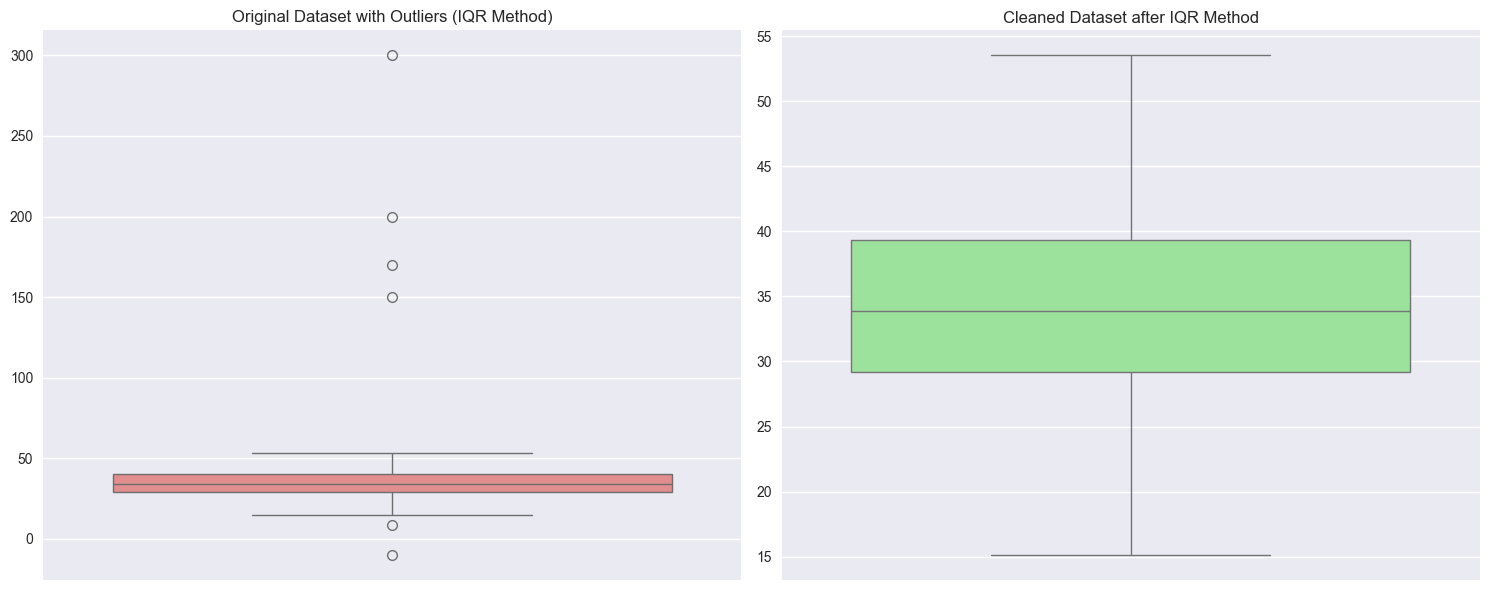

In [12]:
# Plot comparison for IQR method
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(y=data_iqr, ax=axes[0], color='lightcoral')
axes[0].set_title('Original Dataset with Outliers (IQR Method)')

sns.boxplot(y=cleaned_iqr, ax=axes[1], color='lightgreen')
axes[1].set_title('Cleaned Dataset after IQR Method')

plt.tight_layout()
plt.show()